In [1]:
import xgboost as xgb
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_squared_error
import os
#import warnings, itertools
import folium



import sys
from pathlib import Path

project_root = Path("/Users/kristineandersen/Desktop/Speciale/Thesis_project")
sys.path.append(str(project_root))

# data
from Scripts.CleanDataPreliminary import *

Working directory set to: /Users/kristineandersen/Desktop/Speciale/Thesis_project


In [2]:
# set wd
os.chdir('/Users/kristineandersen/Desktop/Speciale')

In [3]:
# Basic info
print(f'Length of dataset: {len(dataset_filtered)}')

max_date = dataset_filtered['date'].max()
min_date = dataset_filtered['date'].min()


print(f'Max date: {max_date}')
print(f'Min date: {min_date}')
print(f'Date range (days): {(max_date - min_date).days}')

print(f'Max n: {dataset_filtered["n"].max()}')
print(f'Min n: {dataset_filtered["n"].min()}')

print(f'Number of different names: {dataset_filtered["name"].nunique()}')

Length of dataset: 31919
Max date: 2020-02-29 00:00:00
Min date: 2013-10-28 00:00:00
Date range (days): 2315
Max n: 88
Min n: 1
Number of different names: 62


In [4]:
# pin hospitals on map
map_center = [dataset_filtered['y_lat'].mean(), dataset_filtered['x_lon'].mean()]
hospital_map = folium.Map(location=map_center, zoom_start=6)

for idx, row in dataset_filtered.drop_duplicates(subset=['Hospital ID']).iterrows():
    folium.Marker(
        location=[row['y_lat'], row['x_lon']],
        popup=f"{row['name']} ({row['region']})",
        tooltip=f"{row['name']} - {row['region']}"
    ).add_to(hospital_map)

hospital_map.save("Thesis_project/hospital_map.html")

# Baseline (naïve persistence)

In [5]:
# drop irrelevant column
BL = dataset_filtered.drop(columns=['name', 'size', 'Hospital ID', 'y_lat', 'x_lon', 'region', 'city'])
# Aggregate to daily counts
BL_Agg = BL.groupby('date').sum().reset_index()
# add day of week
BL_Agg['day_of_week'] = BL_Agg['date'].dt.dayofweek
# add binary weekend column
BL_Agg['is_weekend'] = BL_Agg['day_of_week'].apply(lambda x: 1 if x >=5 else 0)
# add month column
BL_Agg['month'] = BL_Agg['date'].dt.month
# add day of month column
BL_Agg['day_of_month'] = BL_Agg['date'].dt.day
# rearrange columns
BL_Agg = BL_Agg[['date', 'day_of_week', 'is_weekend', 'month', 'day_of_month', 'is_holiday', 'n']]


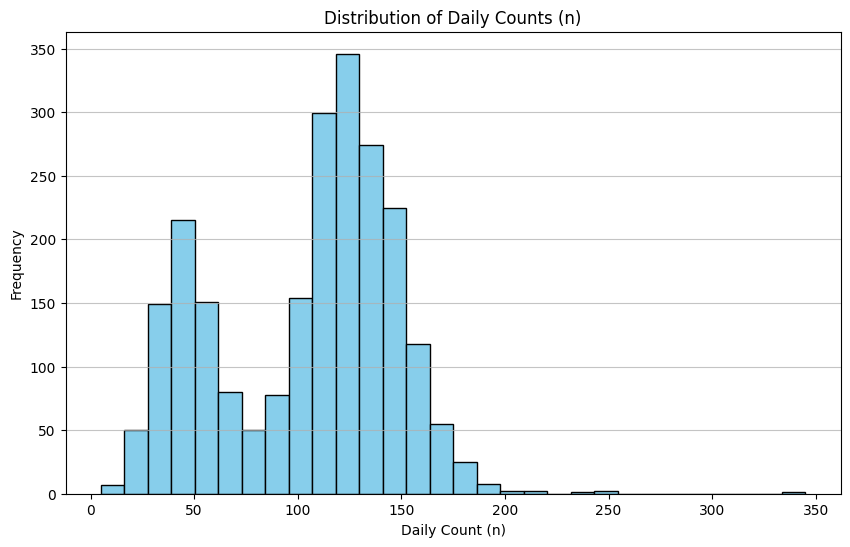

In [6]:
# plot distribution of n
plt.figure(figsize=(10, 6))
plt.hist(BL_Agg['n'], bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution of Daily Counts (n)')
plt.xlabel('Daily Count (n)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

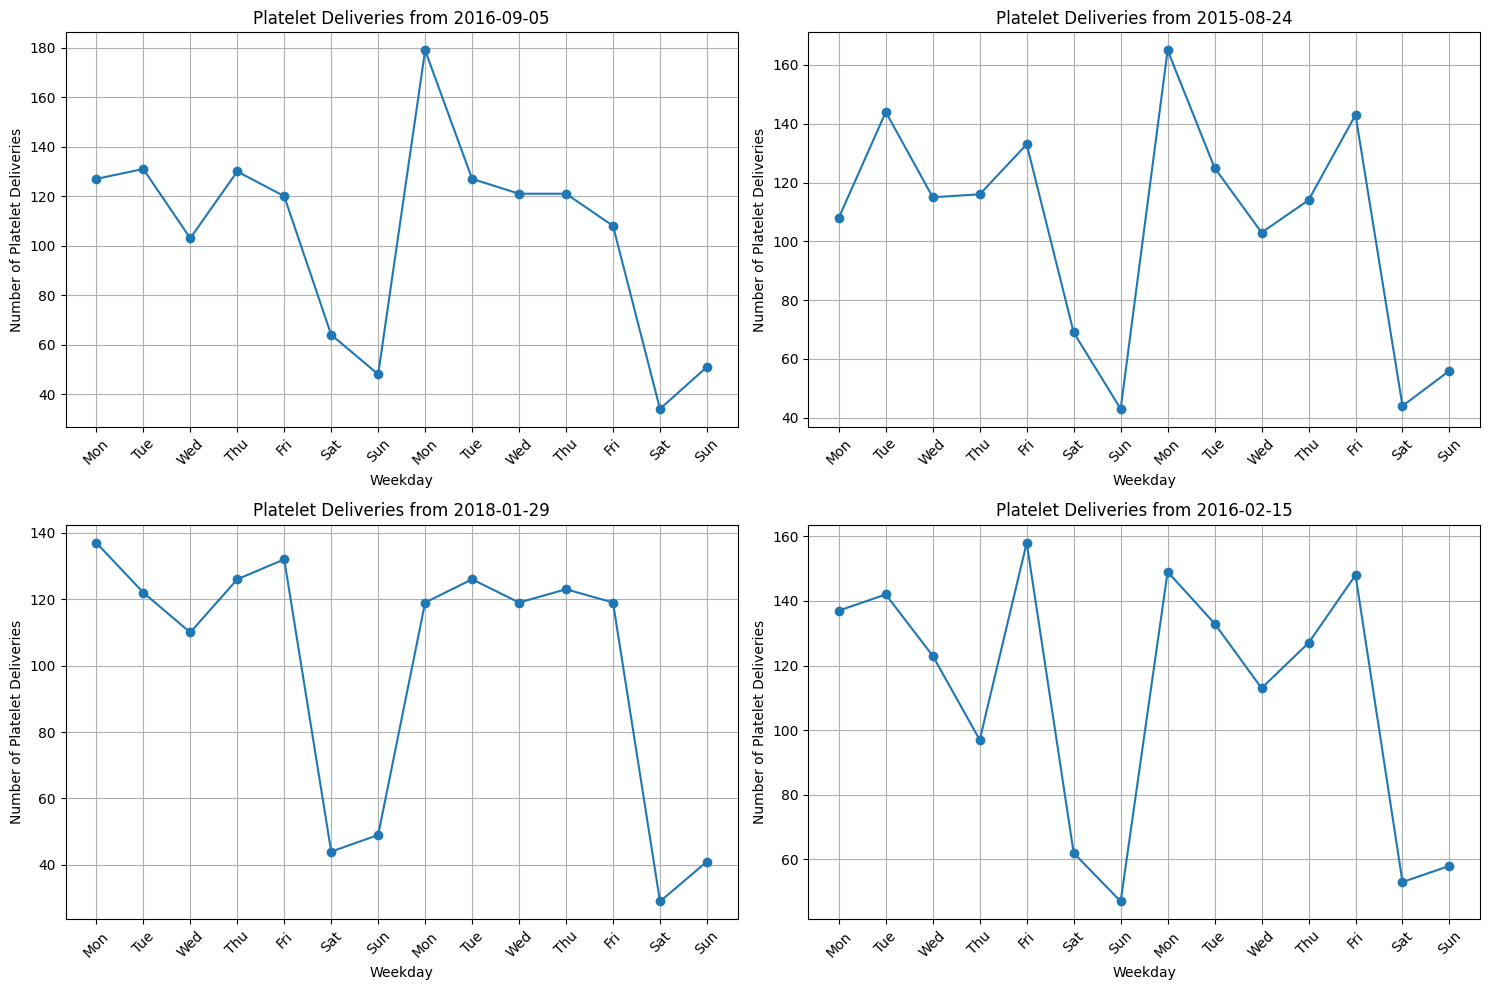

In [7]:
# set seed for reproducibility
np.random.seed(43)
# look at 4 random weeks starting on Mondays, showing 14 days forward
sample_weeks = np.random.choice(range(len(BL_Agg) - 14), size=4, replace=False)
# filter to only Mondays
monday_indices = BL_Agg[BL_Agg['day_of_week'] == 0].index.tolist()
sample_weeks = np.random.choice(monday_indices[:-1], size=4, replace=False)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

weekday_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

for i, week_start in enumerate(sample_weeks):
    week_data = BL_Agg.iloc[week_start:week_start+14]
    axes[i].plot(range(len(week_data)), week_data['n'].values, marker='o')
    axes[i].set_xlabel('Weekday')
    axes[i].set_ylabel('Number of Platelet Deliveries')
    axes[i].set_title(f'Platelet Deliveries from {week_data["date"].iloc[0].date()}')
    axes[i].set_xticks(range(14))
    axes[i].set_xticklabels([weekday_names[int(d)] for d in week_data['day_of_week'].values], rotation=45)
    axes[i].grid()

plt.tight_layout()
plt.show()

In [8]:
# predict with naive method
def predict_next_14_days(data):
    history = data['n'].tolist()
    preds = []

    for _ in range(14):
        pred = (history[-7] + history[-14] + history[-21]) / 3
        preds.append(pred)
        history.append(pred)  # roll forward
    return preds

In [9]:
evaluation_results_BL = dict()
tolerance = 0.0001
rmse_all_BL = []
mse_all_BL = []
mae_all_BL = []
std_all_BL = []

# Start the random start value between 21 and len(BL_Agg) - 14
np.random.seed(23)
start = np.random.randint(22, len(BL_Agg) - 21)
count = 0
while True:
    count += 1
    train_data_BL_rand = BL_Agg.iloc[:-start]
    test_data_BL_rand = BL_Agg.iloc[-start:-start+14]
    predicted_values_BL_rand = predict_next_14_days(train_data_BL_rand)

    mae_BL_rand = mean_absolute_error(test_data_BL_rand['n'], predicted_values_BL_rand)
    mse_BL_rand = mean_squared_error(test_data_BL_rand['n'], predicted_values_BL_rand)
    rmse_BL_rand = np.sqrt(mse_BL_rand)
    evaluation_results_BL = {
        'MAE': mae_BL_rand,
        'MSE': mse_BL_rand,
        'RMSE': rmse_BL_rand
    }
    
    residuals = np.array(test_data_BL_rand['n']) - np.array(predicted_values_BL_rand)
    sigma = residuals.std(ddof=1)
    std_all_BL.append(sigma)

    #print(f'Start Index: {start} | MAE: {mae_BL_rand} | MSE: {mse_BL_rand} | RMSE: {rmse_BL_rand}')

    # Check stopping criterion
    if rmse_all_BL and abs((sum(rmse_all_BL)/len(rmse_all_BL))-((sum(rmse_all_BL)+rmse_BL_rand)/(len(rmse_all_BL)+1))) < tolerance:
        break

    rmse_all_BL.append(rmse_BL_rand)
    mse_all_BL.append(mse_BL_rand)
    mae_all_BL.append(mae_BL_rand)



    start = np.random.randint(22, len(BL_Agg) - 21)

print(f'Total iterations: {count}')

print(f'Final RMSE: {np.mean(rmse_all_BL)}')
print(f'Final MAE: {np.mean(mae_all_BL)}')
print(f'Final MSE: {np.mean(mse_all_BL)}')
print(f'Final Std Dev: {np.mean(std_all_BL)}')

Total iterations: 308
Final RMSE: 26.09698952814327
Final MAE: 20.362907812419213
Final MSE: 772.6262229345833
Final Std Dev: 26.12635286219421


# XGBoost (scenario 1)

In [10]:
# drop irrelevant column
S1 = dataset_filtered.drop(columns=['name', 'size', 'Hospital ID', 'y_lat', 'x_lon', 'region', 'city'])
# Aggregate to daily counts
S1_Agg = S1.groupby('date').sum().reset_index()
# add day of week
S1_Agg['day_of_week'] = S1_Agg['date'].dt.dayofweek
# add binary weekend column
S1_Agg['is_weekend'] = S1_Agg['day_of_week'].apply(lambda x: 1 if x >=5 else 0)
# add month column
S1_Agg['month'] = S1_Agg['date'].dt.month
# add year column
S1_Agg['year'] = S1_Agg['date'].dt.year
# add day of month column
S1_Agg['day_of_month'] = S1_Agg['date'].dt.day
# rearrange columns
S1_Agg = S1_Agg[['date', 'day_of_week', 'is_weekend', 'month', 'year', 'day_of_month', 'is_holiday', 'n']]
S1_Agg.tail(10)

,date,day_of_week,is_weekend,month,year,day_of_month,is_holiday,n
2282,2020-02-20,3,0,2,2020,20,0,105
2283,2020-02-21,4,0,2,2020,21,0,117
2284,2020-02-22,5,1,2,2020,22,0,47
2285,2020-02-23,6,1,2,2020,23,0,21
2286,2020-02-24,0,0,2,2020,24,0,106
2287,2020-02-25,1,0,2,2020,25,0,122
2288,2020-02-26,2,0,2,2020,26,0,120
2289,2020-02-27,3,0,2,2020,27,0,106
2290,2020-02-28,4,0,2,2020,28,0,131
2291,2020-02-29,5,1,2,2020,29,0,37


In [12]:
n = 600
tolerance = 0.0001
rmse_all_s1 = []
mse_all_s1 = []
mae_all_s1 = []
std_all_s1 = []

evaluation_results_S1 = dict()
np.random.seed(397)

start = np.random.randint(720, len(S1_Agg) - 14)
count = 0

while True:
    count += 1
    train_data_S1_rand = S1_Agg.iloc[:-start]
    test_data_S1_rand = S1_Agg.iloc[-start:-start+14]

    # predict next 14 days with XGBoost model
    X_train_s1 = train_data_S1_rand.iloc[:, 1:7]
    y_train_S1 = train_data_S1_rand.iloc[:, 7].values
    xgb_train_S1 = xgb.DMatrix(X_train_s1, y_train_S1, enable_categorical=True)

    params = {
        'objective': 'count:poisson',
        'max_depth': 4,
        'learning_rate': 0.03,
    }
    model = xgb.train(params=params, dtrain=xgb_train_S1, num_boost_round=n)
    predicted_values_S1_rand = model.predict(xgb.DMatrix(test_data_S1_rand.iloc[:, 1:7], enable_categorical=True))
    predicted_values_S1_rand = np.round(predicted_values_S1_rand)

    mae_S1_rand = mean_absolute_error(test_data_S1_rand['n'], predicted_values_S1_rand)
    mse_S1_rand = mean_squared_error(test_data_S1_rand['n'], predicted_values_S1_rand)
    rmse_S1_rand = np.sqrt(mse_S1_rand)
    evaluation_results_S1[start] = {
        'MAE': mae_S1_rand,
        'MSE': mse_S1_rand,
        'RMSE': rmse_S1_rand
    }
    # Residuals
    residuals = test_data_S1_rand['n'].values - predicted_values_S1_rand
    # Standard deviation of prediction error
    sigma_S1_rand = residuals.std(ddof=1)
    std_all_s1.append(sigma_S1_rand)
    #print(f'Start Index: {start} | MAE: {mae_S1_rand} | MSE: {mse_S1_rand} | RMSE: {rmse_S1_rand}')

    # Check stopping criterion
    if rmse_all_s1 and abs((sum(rmse_all_s1)/len(rmse_all_s1))-((sum(rmse_all_s1)+rmse_S1_rand)/(len(rmse_all_s1)+1))) < tolerance:
        break
    
    rmse_all_s1.append(rmse_S1_rand)
    mse_all_s1.append(mse_S1_rand)
    mae_all_s1.append(mae_S1_rand)

    start = np.random.randint(720, len(S1_Agg) - 14)

print(f'Total iterations: {count}')

print(f'Final RMSE: {np.mean(rmse_all_s1)}')
print(f'Final MAE: {np.mean(mae_all_s1)}')
print(f'Final MSE: {np.mean(mse_all_s1)}')
print(f'Final Std Dev: {np.mean(std_all_s1)}')


Total iterations: 418
Final RMSE: 20.322925346949454
Final MAE: 16.27081190882255
Final MSE: 468.21976719771646
Final Std Dev: 19.538735049888913


# XGBoost (scenairo 2)

In [13]:
S2 = dataset_filtered.copy()
# add day of week
S2['day_of_week'] = dataset_filtered['date'].dt.dayofweek
# add binary weekend column
S2['is_weekend'] = S2['day_of_week'].apply(lambda x: 1 if x >=5 else 0)
# add month column
S2['month'] = S2['date'].dt.month
# add year column
S2['year'] = S2['date'].dt.year
# add day of month column
S2['day_of_month'] = S2['date'].dt.day
# Rearrange columns
S2 = S2[['date', 'day_of_week', 'is_weekend', 'month', 'year', 'day_of_month', 'is_holiday', 'name', 'size', 'Hospital ID', 'y_lat', 'x_lon', 'region', 'n']]
S2.tail(10)


,date,day_of_week,is_weekend,month,year,day_of_month,is_holiday,name,size,Hospital ID,y_lat,x_lon,region,n
31909,2020-02-28,4,0,2,2020,28,0,"KYMKS VERIKESKUS, KOTKA",large,9,60.47,26.95,southeast,3
31910,2020-02-28,4,0,2,2020,28,0,"EKKS VERIKESKUS, LAPPEENRANTA",medium,26,61.06,28.19,mid-east,6
31911,2020-02-28,4,0,2,2020,28,0,VAASAN KS VERIKESKUS,medium,11,63.10,21.62,northwest,8
31912,2020-02-28,4,0,2,2020,28,0,ISLAB KUOPIO VERIKESKUS,large,13,62.89,27.68,mid-east,8
31913,2020-02-28,4,0,2,2020,28,0,NORDLAB KAJAANI VERIKESKUS,medium,31,64.23,27.73,northeast,3
31914,2020-02-28,4,0,2,2020,28,0,NORDLAB OULU VERIKESKUS,large,15,65.01,25.47,northeast,23
31915,2020-02-29,5,1,2,2020,29,0,HUSLAB TÖÖLÖN SAIRAALA,medium,17,60.18,24.92,southeast,1
31916,2020-02-29,5,1,2,2020,29,0,HUSLAB MEILAHTI VERIKESKUS,large,1,60.19,24.94,southeast,26
31917,2020-02-29,5,1,2,2020,29,0,FIMLAB HÄMEENLINNA VERIKESKUS,medium,19,61.00,24.47,mid-west,4
31918,2020-02-29,5,1,2,2020,29,0,FIMLAB TAMPERE VERIKESKUS,large,7,61.50,23.76,mid-west,6


In [14]:
# Make name and region categorical variables
S2['name'] = S2['name'].astype('category')
S2['region'] = S2['region'].astype('category')

In [15]:
n=1200
tolerance = 0.0001

evaluation_results_S2 = dict()
np.random.seed(55)

# Ensure start index leaves enough data for training and testing
#start = np.random.randint(720, len(S1) - 14)
S2['date'] = pd.to_datetime(S2['date'])

max_days = (S2['date'].max() - S2['date'].min()).days
start = np.random.randint(720, max_days - 14)
count = 0
rmse_all_s2 = []
mse_all_s2 = []
mae_all_s2 = []
std_all_s2 = []
while True:
    count += 1
    cutoff = S2['date'].max() - pd.Timedelta(days=start) + pd.Timedelta(days=1)
    #cutoff = S2['date'].max() - pd.Timedelta(days=start) + pd.Timedelta(days=1)
    train_data_S2_rand = S2[S2['date'] < cutoff]
    test_data_S2_rand = S2[(S2['date'] >= cutoff)]
    #test_data_S2_rand = S2[(S2['date'] >= cutoff) & (S2['date'] < cutoff + pd.Timedelta(days=14))]

    # Predict next 14 days with XGBoost model
    X_train_S2_rand = train_data_S2_rand.iloc[:, 1:13]
    y_train_S2_rand = train_data_S2_rand.iloc[:, 13].values
    xgb_train_S2_rand = xgb.DMatrix(X_train_S2_rand, y_train_S2_rand, enable_categorical=True)

    params = {
        'objective': 'reg:squarederror',
        'max_depth': 6,
        'learning_rate': 0.03,
    }
    model = xgb.train(params=params, dtrain=xgb_train_S2_rand, num_boost_round=n)

    # Evaluate on test set
    X_test_S2_rand = test_data_S2_rand.iloc[:, 1:13]
    xgb_test_S2_rand = xgb.DMatrix(X_test_S2_rand, enable_categorical=True)
    predicted_values_S2_rand = model.predict(xgb_test_S2_rand)
    predicted_values_S2_rand = np.round(predicted_values_S2_rand)

    # Aggregate predictions by date
    S2_test_results_rand = test_data_S2_rand.copy()
    S2_test_results_rand['predicted'] = predicted_values_S2_rand

    S2_daily_agg_rand = S2_test_results_rand.groupby('date').agg({
        'n': 'sum',
        'predicted': 'sum'
    }).reset_index()

    # Calculate evaluation metrics
    mae_S2_rand = mean_absolute_error(test_data_S2_rand['n'], predicted_values_S2_rand)
    mse_S2_rand = mean_squared_error(test_data_S2_rand['n'], predicted_values_S2_rand)
    rmse_S2_rand = np.sqrt(mse_S2_rand)
    evaluation_results_S2[start] = {
        'MAE': mae_S2_rand,
        'MSE': mse_S2_rand,
        'RMSE': rmse_S2_rand
    }

    # Residuals
    residuals = test_data_S2_rand['n'].values - predicted_values_S2_rand
    # Standard deviation of prediction error
    sigma_S2_rand = residuals.std(ddof=1)
    std_all_s2.append(sigma_S2_rand)

    #print(f'Start Index: {start} | MAE: {mae_S2_rand} | MSE: {mse_S2_rand} | RMSE: {rmse_S2_rand}')

    # Check stopping criterion
    if rmse_all_s2 and abs((sum(rmse_all_s2)/len(rmse_all_s2))-((sum(rmse_all_s2)+rmse_S2_rand)/(len(rmse_all_s2)+1))) < tolerance:
        break
    
    rmse_all_s2.append(rmse_S2_rand)
    mse_all_s2.append(mse_S2_rand)
    mae_all_s2.append(mae_S2_rand)

    start = np.random.randint(720, max_days - 14)

print(f'Total iterations: {count}')

print(f'Final RMSE: {np.mean(rmse_all_s2)}')
print(f'Final MAE: {np.mean(mae_all_s2)}')
print(f'Final MSE: {np.mean(mse_all_s2)}')
print(f'Final Std Dev: {np.mean(std_all_s2)}')

Total iterations: 195
Final RMSE: 4.826283113109632
Final MAE: 3.0981572153642007
Final MSE: 23.766775652305366
Final Std Dev: 4.7934993173038025


# ARIMA

In [23]:
# drop irrelevant column
model_ARIMA = dataset_filtered.drop(columns=['name', 'size', 'Hospital ID', 'y_lat', 'x_lon', 'region', 'city', 'is_holiday'])
# Aggregate to daily counts
model_ARIMA_Agg = model_ARIMA.groupby('date').sum().reset_index()
model_ARIMA_Agg.tail(10)

,date,n
2282,2020-02-20,105
2283,2020-02-21,117
2284,2020-02-22,47
2285,2020-02-23,21
2286,2020-02-24,106
2287,2020-02-25,122
2288,2020-02-26,120
2289,2020-02-27,106
2290,2020-02-28,131
2291,2020-02-29,37


In [24]:
model_ARIMA_Agg['date'] = pd.to_datetime(model_ARIMA_Agg['date'])
model_ARIMA_Agg = model_ARIMA_Agg.sort_values('date')

y = model_ARIMA_Agg.set_index('date')['n']
y = y.asfreq('D')
y = y.fillna(0)


In [25]:
y = pd.Series(y)

def find_d(series, max_d=2):
    s = series.copy()
    for d in range(max_d + 1):
        p = adfuller(s.dropna())[1]
        if p < 0.05:
            return d
        s = s.diff()
    return max_d

d = find_d(y)
print("d =", d)
h = 14
train, test = y.iloc[:-h], y.iloc[-h:]


d = 0


In [26]:
import pandas as pd
from statsmodels.tsa.stattools import adfuller, kpss

y = pd.Series(y)

def find_d_adf_kpss(series, max_d=2, alpha=0.05, kpss_reg="c"):
    """
    Choose smallest d such that:
      - ADF rejects unit root  (p_adf < alpha)  -> evidence for stationarity
      - KPSS fails to reject stationarity (p_kpss > alpha)
    kpss_reg:
      - "c"  : level-stationary
      - "ct" : trend-stationary
    """
    s = series.copy()

    for d in range(max_d + 1):
        x = s.dropna()

        # ADF (H0: unit root / non-stationary)
        p_adf = adfuller(x, autolag="AIC")[1]

        # KPSS (H0: stationary)
        # KPSS can throw warnings/errors if series is very flat or too short.
        try:
            p_kpss = kpss(x, regression=kpss_reg, nlags="auto")[1]
        except Exception:
            p_kpss = 0.0  # treat as "fails stationarity" -> keep differencing

        if (p_adf < alpha) and (p_kpss > alpha):
            return d, {"p_adf": p_adf, "p_kpss": p_kpss}

        s = s.diff()

    # fallback: return max_d and last p-values
    x = s.dropna()
    p_adf = adfuller(x, autolag="AIC")[1]
    try:
        p_kpss = kpss(x, regression=kpss_reg, nlags="auto")[1]
    except Exception:
        p_kpss = 0.0
    return max_d, {"p_adf": p_adf, "p_kpss": p_kpss}


d, stats = find_d_adf_kpss(y, max_d=2, alpha=0.05, kpss_reg="ct")
print(f"d = {d}  (ADF p={stats['p_adf']:.4g}, KPSS p={stats['p_kpss']:.4g})")

h = 14
train, test = y.iloc[:-h], y.iloc[-h:]


d = 0  (ADF p=1.78e-22, KPSS p=0.1)


/var/folders/76/scy6w4151918bj9rvtfnfyw00000gn/T/ipykernel_22023/4057877748.py:26: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  p_kpss = kpss(x, regression=kpss_reg, nlags="auto")[1]


In [ ]:
warnings.filterwarnings("ignore")

p = q = range(0, 6)
d = range(0, 1)

best = None
best_aic = float("inf")

for order in itertools.product(p, d, q):
    try:
        res = ARIMA(train, order=order,
                    enforce_stationarity=False,
                    enforce_invertibility=False).fit()

        if not res.mle_retvals.get("converged", False):
            continue

        if res.aic < best_aic:
            best_aic = res.aic
            best = order
    except Exception:
        pass


In [32]:
print(f"Best ARIMA order: {best} with AIC: {best_aic:.2f}")

Best ARIMA order: (5, 0, 4) with AIC: 22326.57


In [29]:
tolerance = 0.0001
np.random.seed(55)

# Ensure start index leaves enough data for training and testing

start = np.random.randint(720, len(model_ARIMA_Agg) - 14)
count = 0
rmse_all_ARIMA = []
mse_all_ARIMA = []
mae_all_ARIMA = []
std_all_ARIMA = []
evaluation_results_ARIMA = dict()

while True:
    train_data_ARIMA_rand = y.iloc[:-start]
    test_data_ARIMA_rand = y.iloc[-start:-start+14]

    model_ARIMA_rand = ARIMA(train_data_ARIMA_rand, order=best,
                        enforce_stationarity=False,
                        enforce_invertibility=False).fit()
    forecast_ARIMA_rand = model_ARIMA_rand.forecast(steps=14)

    mae_ARIMA_rand = mean_absolute_error(test_data_ARIMA_rand, forecast_ARIMA_rand)
    mse_ARIMA_rand = mean_squared_error(test_data_ARIMA_rand, forecast_ARIMA_rand)
    rmse_ARIMA_rand = np.sqrt(mse_ARIMA_rand)
    evaluation_results_ARIMA[start] = {
        'MAE': mae_ARIMA_rand,
        'MSE': mse_ARIMA_rand,
        'RMSE': rmse_ARIMA_rand
    }
    residuals = (test_data_ARIMA_rand.values - forecast_ARIMA_rand.values)
    sigma = residuals.std(ddof=1)
    std_all_ARIMA.append(sigma)

    #print(f'Start Index: {start} | MAE: {mae_ARIMA_rand} | MSE: {mse_ARIMA_rand} | RMSE: {rmse_ARIMA_rand}')
    # Check stopping criterion
    if rmse_all_ARIMA and abs((sum(rmse_all_ARIMA)/len(rmse_all_ARIMA))-((sum(rmse_all_ARIMA)+rmse_ARIMA_rand)/(len(rmse_all_ARIMA)+1))) < tolerance:
        break
    count += 1
    rmse_all_ARIMA.append(rmse_ARIMA_rand)
    mse_all_ARIMA.append(mse_ARIMA_rand)
    mae_all_ARIMA.append(mae_ARIMA_rand)
    start = np.random.randint(720, len(model_ARIMA_Agg) - 14)

print(f'Total iterations: {count}')
print(f'Final RMSE: {np.mean(rmse_all_ARIMA)}')
print(f'Final MAE: {np.mean(mae_all_ARIMA)}')
print(f'Final MSE: {np.mean(mse_all_ARIMA)}')
print(f'Final Std Dev: {np.mean(std_all_ARIMA)}')

Total iterations: 567
Final RMSE: 29.071632177849892
Final MAE: 23.575468123438732
Final MSE: 954.8518066807708
Final Std Dev: 28.68117048282321


# Evaluation

In [30]:
results_BL = dict({
        'MAE': np.mean(mae_all_BL),
        'MSE': np.mean(mse_all_BL),
        'RMSE': np.mean(rmse_all_BL)
})
results_S1 = dict({
        'MAE': np.mean(mae_all_s1),
        'MSE': np.mean(mse_all_s1),
        'RMSE': np.mean(rmse_all_s1)
})
results_S2 = dict({
        'MAE': np.mean(mae_all_s2),
        'MSE': np.mean(mse_all_s2),
        'RMSE': np.mean(rmse_all_s2)
})
results_ARIMA = dict({
        'MAE': np.mean(mae_all_ARIMA),
        'MSE': np.mean(mse_all_ARIMA),
        'RMSE': np.mean(rmse_all_ARIMA)
})

all_models_evaluation = {
    'Baseline': results_BL,
    'XGBoost_S1': results_S1,
    'XGBoost_S2': results_S2,
    'ARIMA': results_ARIMA}

In [31]:
summary_data = []

for model_name in all_models_evaluation:
    summary_data.append({
        'Model': model_name,
        'Average MAE': all_models_evaluation[model_name]['MAE'],
        'Average MSE': all_models_evaluation[model_name]['MSE'],
        'Average RMSE': all_models_evaluation[model_name]['RMSE']
    })

summary_table = pd.DataFrame(summary_data)
summary_table = summary_table.sort_values('Average MAE')
print(summary_table.to_string(index=False))


     Model  Average MAE  Average MSE  Average RMSE
XGBoost_S2     3.098157    23.766776      4.826283
XGBoost_S1    16.270812   468.219767     20.322925
  Baseline    20.362908   772.626223     26.096990
     ARIMA    23.575468   954.851807     29.071632
